# Validação visual — eleição multi-partidária e hierarquia de granularidade

Este notebook é material de revisão para a reunião com os orientadores, não
parte do pipeline de produção. Ele valida visualmente a extensão da Camada 1
que introduz competição eleitoral real (escolha de candidato) e a hierarquia
de granularidade seção → município → estado (g do PLANO §5.1.2), substituindo
o proxy anterior de R (só adesão+conformidade) por um resultado eleitoral com
concorrência entre candidatos.

**Por que um notebook novo, não uma extensão do
`validacao_visual_desistencia.ipynb`:** aquele notebook já é longo e focado
especificamente no mecanismo de conformidade/desistência; este mecanismo é
outro eixo (competição eleitoral + granularidade). Manter cada notebook
coeso e navegável antes da reunião.

**Contexto do mecanismo:** cada agente sorteia, uma única vez na criação, um
`candidato_preferido` (voto de base, categórico uniforme sobre
`range(n_candidatos)` — sem preferência ideológica/demográfica, decisão v0).
O voto final de um agente é `candidato_alvo` (do adversário) se
`aderiu and votou_conforme`; senão, seu `candidato_preferido`. Com
`n_candidatos=1` (default) esse mecanismo fica inteiramente desativado —
`candidato_preferido` nunca é consultado — reproduzindo exatamente o
comportamento anterior a esta funcionalidade. O gerador não implementa
alocação de cadeiras (quociente eleitoral, D'Hondt, sobras) — `resultado_alvo`
é reusado como a fração de votos válidos que o candidato-alvo precisa
atingir, suficiente para simular um quociente pequeno de sistema proporcional
sem formalizar a regra de alocação.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from src.generator.layer1_abm import ElectionModel

plt.rcParams["figure.dpi"] = 100
print(f"Projeto em: {PROJECT_ROOT}")

C:\Users\Dell\Desktop\TCC_Projeto\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Projeto em: C:\Users\Dell\Desktop\TCC_Projeto


## 1. O mesmo número absoluto de votos comprados, mais candidatos

Fixamos os parâmetros de Fase 1 (`recompensa`, `threshold_range`,
`prob_conformidade`) — logo a adesão bruta e a fração de conformes são
**idênticas** em todos os cenários abaixo, já que a decisão de adesão não
depende de `n_candidatos`. Variamos só `n_candidatos ∈ {1, 3, 6, 10}` e
observamos o resultado do candidato-alvo (`fonte_c_resultado_agregado()`).

**O que esperar, e por quê:** com `n_candidatos=1`, o resultado é só a fração
de conformes (nenhum voto de base entra — ver nota de escopo no código). Com
`n_candidatos>1`, cada agente que NÃO foi comprado ainda "vota" em algum
candidato (`candidato_preferido`), e uma fração `1/n_candidatos` desses votos
de base cai, por coincidência, no candidato-alvo. Como a adesão comprada é
fixa e pequena aqui (parâmetros calibrados para ~2-3%), esse "bônus" de
voto de base coincidente passa a dominar o resultado — o MESMO número
absoluto de votos comprados passa a representar uma fração muito maior do
total conforme `n_candidatos` cresce. Isso ilustra exatamente por que um
quociente pequeno de sistema proporcional (mais candidatos disputando)
torna a detecção mais sensível a esse tipo de ruído de base.

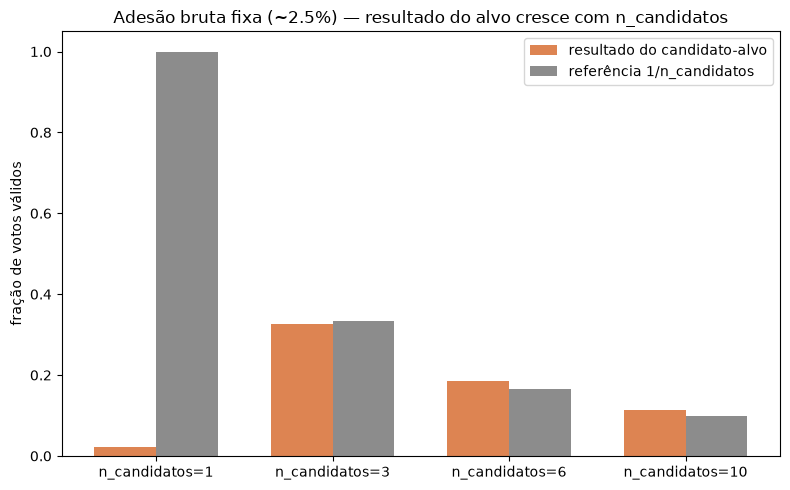

n_candidatos=1: adesão bruta=0.0255  resultado do alvo=0.0220  1/n_candidatos=1.0000
n_candidatos=3: adesão bruta=0.0255  resultado do alvo=0.3275  1/n_candidatos=0.3333
n_candidatos=6: adesão bruta=0.0255  resultado do alvo=0.1855  1/n_candidatos=0.1667
n_candidatos=10: adesão bruta=0.0255  resultado do alvo=0.1125  1/n_candidatos=0.1000


In [2]:
valores_nc = [1, 3, 6, 10]
resultados = []
bruta_adesao = []

for nc in valores_nc:
    modelo = ElectionModel(
        n_agentes=2000,
        prop_racional=1.0,
        recompensa=1.0,
        threshold_range=(0.85, 0.95),
        prob_conformidade=0.9,
        n_candidatos=nc,
        seed=11,
    )
    modelo.run()
    resultados.append(modelo.fonte_c_resultado_agregado())
    bruta_adesao.append(modelo.fracao_adesao())

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(valores_nc))
largura = 0.35

barras_resultado = ax.bar(x - largura / 2, resultados, largura, label="resultado do candidato-alvo", color="#DD8452")
barras_quociente = ax.bar(x + largura / 2, [1 / nc for nc in valores_nc], largura, label="referência 1/n_candidatos", color="#8C8C8C")

ax.set_xticks(x)
ax.set_xticklabels([f"n_candidatos={nc}" for nc in valores_nc])
ax.set_ylabel("fração de votos válidos")
ax.set_title("Adesão bruta fixa (~%.1f%%) — resultado do alvo cresce com n_candidatos" % (100 * np.mean(bruta_adesao)))
ax.legend()
fig.tight_layout()
plt.show()

for nc, r, b in zip(valores_nc, resultados, bruta_adesao):
    print(f"n_candidatos={nc}: adesão bruta={b:.4f}  resultado do alvo={r:.4f}  1/n_candidatos={1/nc:.4f}")

**Leitura:** a barra laranja (resultado do candidato-alvo) sobe de
forma acentuada de `n_candidatos=1` para `n_candidatos=3` e depois acompanha
de perto a barra cinza (`1/n_candidatos`, o "piso" de voto de base) — porque
a adesão comprada, fixa e pequena, é uma fração cada vez menor do que está
empurrando o resultado do alvo para cima. Note que a adesão bruta (impresso
abaixo do gráfico) é a mesma em todos os cenários — a diferença inteira do
resultado vem do mecanismo de voto de base, não de mais gente aderindo.

## 2. Resultado nos três níveis de granularidade

Construímos um cenário com hierarquia não trivial (mais de uma seção por
município, mais de um município por estado) e mostramos o resultado do
candidato-alvo em cada nível — seção, município e estado — lado a lado,
confirmando que a agregação hierárquica funciona como esperado (município e
estado são médias ponderadas pelas seções/municípios que os compõem).

n_secoes=12  n_municipios=3  n_estados=1


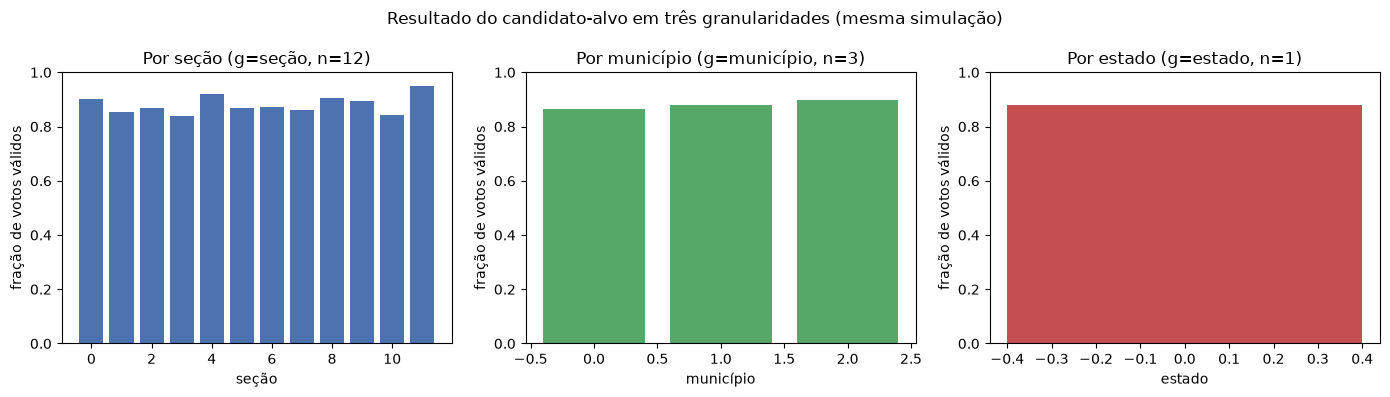

fonte_c_resultado_agregado() (pool inteiro) = 0.8800
resultado_eleitoral_por_estado() (1 estado só, hierarquia colapsa) = 0.8800


In [3]:
modelo_hier = ElectionModel(
    n_agentes=1200,
    n_secoes=12,
    secoes_por_municipio=4,
    municipios_por_estado=3,
    n_candidatos=4,
    prop_racional=1.0,
    recompensa=3.0,
    threshold_range=(0.0, 0.6),
    prob_conformidade=0.85,
    seed=5,
)
modelo_hier.run()

por_secao = modelo_hier.resultado_eleitoral_por_secao()
por_municipio = modelo_hier.resultado_eleitoral_por_municipio()
por_estado = modelo_hier.resultado_eleitoral_por_estado()

print(f"n_secoes={modelo_hier.n_secoes}  n_municipios={modelo_hier.n_municipios}  n_estados={modelo_hier.n_estados}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(por_secao.index, por_secao.values, color="#4C72B0")
axes[0].set_title(f"Por seção (g=seção, n={modelo_hier.n_secoes})")
axes[0].set_xlabel("seção")

axes[1].bar(por_municipio.index, por_municipio.values, color="#55A868")
axes[1].set_title(f"Por município (g=município, n={modelo_hier.n_municipios})")
axes[1].set_xlabel("município")

axes[2].bar(por_estado.index, por_estado.values, color="#C44E52")
axes[2].set_title(f"Por estado (g=estado, n={modelo_hier.n_estados})")
axes[2].set_xlabel("estado")

for ax in axes:
    ax.set_ylabel("fração de votos válidos")
    ax.set_ylim(0, 1.0)

fig.suptitle("Resultado do candidato-alvo em três granularidades (mesma simulação)")
fig.tight_layout()
plt.show()

agregado = modelo_hier.fonte_c_resultado_agregado()
print(f"fonte_c_resultado_agregado() (pool inteiro) = {agregado:.4f}")
print(f"resultado_eleitoral_por_estado() (1 estado só, hierarquia colapsa) = {por_estado.iloc[0]:.4f}")

**Leitura:** o painel da esquerda mostra as 12 seções individuais, com
mais variação (menos agentes por grupo = mais ruído estatístico); o painel do
meio agrega essas seções em 3 municípios (4 seções cada), já mais estável; o
painel da direita colapsa tudo num único estado (3 municípios/estado com
`municipios_por_estado=3`), que deve coincidir numericamente com
`fonte_c_resultado_agregado()` — confirmado pelos dois valores impressos
acima, que devem ser iguais (ou muito próximos, sujeitos a arredondamento de
ponto flutuante).